In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

RANDOM_STATE = 42

In [25]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_train = pd.read_csv("../data/processed/y_train_processed.csv")
y_test = pd.read_csv("../data/processed/y_test_processed.csv")

In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (54054, 7)
X_test shape: (2000, 7)
y_train shape: (54054, 1)
y_test shape: (2000, 1)


In [27]:
X_train.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_2,Type_3
0,-0.652499,-1.015001,-0.521767,1.420045,-0.719316,0,0
1,1.099697,0.471029,0.169978,-0.370404,-0.121186,0,0
2,-1.353378,-1.420282,-0.673614,0.172766,1.232476,0,0
3,0.098442,-0.136892,1.632204,-1.718271,-1.600770,0,0
4,0.348756,-0.136892,-1.162897,1.440163,0.996372,0,0


In [28]:
y_train.head()

,Reason of Failure
0,No Failure
1,No Failure
2,No Failure
3,No Failure
4,No Failure


In [29]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(type(y_train))
print(type(y_test))

print(y_train.shape)
print(y_test.shape)

<class 'pandas.Series'>
<class 'pandas.Series'>
(54054,)
(2000,)


In [30]:
print("Unique values in y_train:")
print(y_train.unique())

print("\nNumber of classes:")
print(y_train.nunique())

Unique values in y_train:
<ArrowStringArray>
['No Failure', 'HDF', 'Multiple Failures', 'PWF', 'OSF', 'RNF', 'TWF']
Length: 7, dtype: str

Number of classes:
7


### Encoding the Target
`Reason of Failure` is text (`No Failure`, `TWF`, ...). XGBoost, LightGBM and CatBoost all expect numeric labels, so we encode it once here and use the same encoded labels for every model — that way all five models are compared on the exact same footing.

In [31]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['HDF' 'Multiple Failures' 'No Failure' 'OSF' 'PWF' 'RNF' 'TWF']


### Cleaning Column Names
XGBoost/LightGBM don't allow `[`, `]` or `<` in feature names (our columns carry units like `Air temperature [K]`), so we strip them before training anything.

In [32]:
X_train.columns = (
    X_train.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print(X_train.columns.tolist())

['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Type_2', 'Type_3']


## Model Training & Evaluation

In [33]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

lr_model.fit(
    X_train,
    y_train_encoded
)

lr_pred = lr_model.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test_encoded, lr_pred)
precision = precision_score(y_test_encoded, lr_pred, average="weighted")
recall = recall_score(y_test_encoded, lr_pred, average="weighted")
f1 = f1_score(y_test_encoded, lr_pred, average="weighted")
recall_macro = recall_score(y_test_encoded, lr_pred, average="macro")
f1_macro = f1_score(y_test_encoded, lr_pred, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Recall (Macro):", recall_macro)
print("F1 Score (Macro):", f1_macro)

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, lr_pred, target_names=label_encoder.classes_))

lr_acc, lr_precision, lr_recall, lr_f1 = accuracy, precision, recall, f1

Accuracy : 0.657
Precision: 0.9717364280270702
Recall   : 0.657
F1 Score : 0.7723992900214703
Recall (Macro): 0.7823719643297734
F1 Score (Macro): 0.37365791680594385

Classification Report:

                   precision    recall  f1-score   support

              HDF       0.21      0.95      0.35        21
Multiple Failures       0.19      1.00      0.31         5
       No Failure       1.00      0.65      0.79      1930
              OSF       0.36      0.81      0.50        16
              PWF       0.41      0.94      0.57        16
              RNF       0.00      0.25      0.00         4
              TWF       0.05      0.88      0.10         8

         accuracy                           0.66      2000
        macro avg       0.32      0.78      0.37      2000
     weighted avg       0.97      0.66      0.77      2000



In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train_encoded
)

rf_pred = rf_model.predict(X_test)


In [36]:
accuracy = accuracy_score(y_test_encoded, rf_pred)
precision = precision_score(y_test_encoded, rf_pred, average="weighted")
recall = recall_score(y_test_encoded, rf_pred, average="weighted")
f1 = f1_score(y_test_encoded, rf_pred, average="weighted")
recall_macro = recall_score(y_test_encoded, rf_pred, average="macro")
f1_macro = f1_score(y_test_encoded, rf_pred, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Recall (Macro):", recall_macro)
print("F1 Score (Macro):", f1_macro)

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, rf_pred, target_names=label_encoder.classes_))

rf_acc, rf_precision, rf_recall, rf_f1 = accuracy, precision, recall, f1

Accuracy : 0.9735
Precision: 0.9768596656217348
Recall   : 0.9735
F1 Score : 0.9743924487250036
Recall (Macro): 0.5814859363434494
F1 Score (Macro): 0.5514870844918649

Classification Report:

                   precision    recall  f1-score   support

              HDF       0.72      1.00      0.84        21
Multiple Failures       1.00      0.40      0.57         5
       No Failure       0.99      0.98      0.99      1930
              OSF       0.70      0.88      0.78        16
              PWF       0.59      0.81      0.68        16
              RNF       0.00      0.00      0.00         4
              TWF       0.00      0.00      0.00         8

         accuracy                           0.97      2000
        macro avg       0.57      0.58      0.55      2000
     weighted avg       0.98      0.97      0.97      2000



c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [37]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

In [38]:
xgb_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train_encoded,
    sample_weight=xgb_weights
)

xgb_pred = xgb_model.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test_encoded, xgb_pred)
precision = precision_score(y_test_encoded, xgb_pred, average="weighted")
recall = recall_score(y_test_encoded, xgb_pred, average="weighted")
f1 = f1_score(y_test_encoded, xgb_pred, average="weighted")
recall_macro = recall_score(y_test_encoded, xgb_pred, average="macro")
f1_macro = f1_score(y_test_encoded, xgb_pred, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Recall (Macro):", recall_macro)
print("F1 Score (Macro):", f1_macro)

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, xgb_pred, target_names=label_encoder.classes_))

xgb_acc, xgb_precision, xgb_recall, xgb_f1 = accuracy, precision, recall, f1

Accuracy : 0.977
Precision: 0.9836591323776475
Recall   : 0.977
F1 Score : 0.979747974306735
Recall (Macro): 0.6263508512213176
F1 Score (Macro): 0.6083768379636272

Classification Report:

                   precision    recall  f1-score   support

              HDF       0.88      1.00      0.93        21
Multiple Failures       1.00      0.40      0.57         5
       No Failure       0.99      0.98      0.99      1930
              OSF       0.75      0.94      0.83        16
              PWF       0.79      0.94      0.86        16
              RNF       0.00      0.00      0.00         4
              TWF       0.05      0.12      0.07         8

         accuracy                           0.98      2000
        macro avg       0.64      0.63      0.61      2000
     weighted avg       0.98      0.98      0.98      2000



In [40]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

lgbm_model.fit(
    X_train,
    y_train_encoded
)

lgbm_pred = lgbm_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1279
[LightGBM] [Info] Number of data points in the train set: 54054, number of used features: 7
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910


In [41]:
accuracy = accuracy_score(y_test_encoded, lgbm_pred)
precision = precision_score(y_test_encoded, lgbm_pred, average="weighted")
recall = recall_score(y_test_encoded, lgbm_pred, average="weighted")
f1 = f1_score(y_test_encoded, lgbm_pred, average="weighted")
recall_macro = recall_score(y_test_encoded, lgbm_pred, average="macro")
f1_macro = f1_score(y_test_encoded, lgbm_pred, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Recall (Macro):", recall_macro)
print("F1 Score (Macro):", f1_macro)

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, lgbm_pred, target_names=label_encoder.classes_))

lgbm_acc, lgbm_precision, lgbm_recall, lgbm_f1 = accuracy, precision, recall, f1

Accuracy : 0.9745
Precision: 0.9818736526266322
Recall   : 0.9745
F1 Score : 0.9777333107559962
Recall (Macro): 0.5840999612280146
F1 Score (Macro): 0.5655207438166523

Classification Report:

                   precision    recall  f1-score   support

              HDF       1.00      0.90      0.95        21
Multiple Failures       0.50      0.20      0.29         5
       No Failure       0.99      0.98      0.99      1930
              OSF       0.70      0.88      0.78        16
              PWF       0.78      0.88      0.82        16
              RNF       0.00      0.00      0.00         4
              TWF       0.09      0.25      0.13         8

         accuracy                           0.97      2000
        macro avg       0.58      0.58      0.57      2000
     weighted avg       0.98      0.97      0.98      2000



In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_encoded)

cat_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

In [43]:
cat_model = CatBoostClassifier(
    iterations=100,
    random_state=RANDOM_STATE,
    verbose=0,
    class_weights=cat_weights
)

cat_model.fit(
    X_train,
    y_train_encoded
)

cat_pred = cat_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test_encoded, cat_pred)
precision = precision_score(y_test_encoded, cat_pred, average="weighted")
recall = recall_score(y_test_encoded, cat_pred, average="weighted")
f1 = f1_score(y_test_encoded, cat_pred, average="weighted")
recall_macro = recall_score(y_test_encoded, cat_pred, average="macro")
f1_macro = f1_score(y_test_encoded, cat_pred, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Recall (Macro):", recall_macro)
print("F1 Score (Macro):", f1_macro)

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, cat_pred, target_names=label_encoder.classes_))

cat_acc, cat_precision, cat_recall, cat_f1 = accuracy, precision, recall, f1

Accuracy : 0.9485
Precision: 0.9754334472573097
Recall   : 0.9485
F1 Score : 0.960128072865832
Recall (Macro): 0.631060325684678
F1 Score (Macro): 0.5183559897865362

Classification Report:

                   precision    recall  f1-score   support

              HDF       0.62      1.00      0.76        21
Multiple Failures       0.50      0.40      0.44         5
       No Failure       0.99      0.95      0.97      1930
              OSF       0.59      1.00      0.74        16
              PWF       0.50      0.81      0.62        16
              RNF       0.00      0.00      0.00         4
              TWF       0.05      0.25      0.08         8

         accuracy                           0.95      2000
        macro avg       0.46      0.63      0.52      2000
     weighted avg       0.98      0.95      0.96      2000



## Model Comparison

In [45]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc, lgbm_acc, cat_acc],
    "Precision": [lr_precision, rf_precision, xgb_precision, lgbm_precision, cat_precision],
    "Recall": [lr_recall, rf_recall, xgb_recall, lgbm_recall, cat_recall],
    "F1 Score": [lr_f1, rf_f1, xgb_f1, lgbm_f1, cat_f1]
})

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.9770,0.983659,0.9770,0.979748
1,LightGBM,0.9745,0.981874,0.9745,0.977733
2,Random Forest,0.9735,0.976860,0.9735,0.974392
3,CatBoost,0.9485,0.975433,0.9485,0.960128
4,Logistic Regression,0.6570,0.971736,0.6570,0.772399


### Confusion Matrix — Best Model

Best model: XGBoost


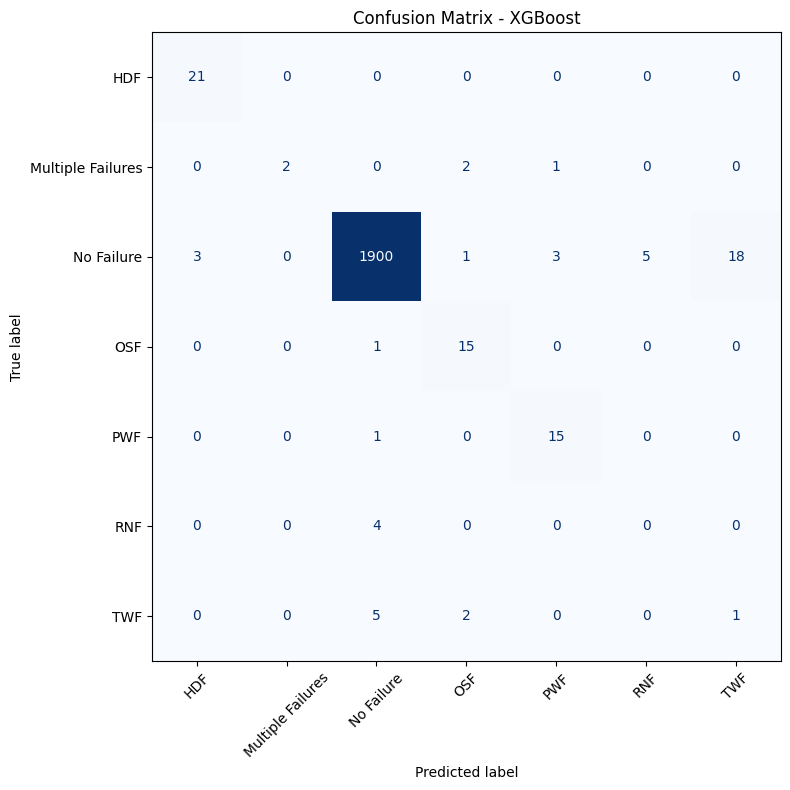

In [46]:
best_model_name = results.loc[0, "Model"]
print("Best model:", best_model_name)

models_lookup = {
    "Logistic Regression": (lr_model, lr_pred),
    "Random Forest": (rf_model, rf_pred),
    "XGBoost": (xgb_model, xgb_pred),
    "LightGBM": (lgbm_model, lgbm_pred),
    "CatBoost": (cat_model, cat_pred)
}

best_model, best_pred = models_lookup[best_model_name]

cm = confusion_matrix(y_test_encoded, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## Save the Final Model

In [47]:
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print(f"Saved {best_model_name} as the final model to ../models/")

Saved XGBoost as the final model to ../models/


After comparing five models (Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost) on accuracy, precision, recall, and F1 score, the best-performing model is picked automatically from the comparison table above and saved as the final model for deployment.

# Test Samples

In [48]:
test_samples = X_test.copy()
test_samples["Failure Type"] = y_test.values

for label in sorted(test_samples["Failure Type"].unique()):
    print("=" * 60)
    print(label)
    display(
        test_samples[
            test_samples["Failure Type"] == label
        ].head(1)
    )

HDF


,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3,Failure Type
57,1.350011,0.268389,-1.303496,1.520632,-1.380407,0,1,HDF


Multiple Failures


,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3,Failure Type
140,0.849384,-0.339533,-1.342864,2.556679,1.909307,0,0,Multiple Failures


No Failure


...

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3,Failure Type
40,0.24863,-0.136892,-1.196641,3.290964,0.807489,0,1,PWF


RNF


,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3,Failure Type
7,0.799321,0.335936,0.366816,-0.782811,-1.663731,0,1,RNF


TWF


,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3,Failure Type
58,-0.902813,-1.622923,-0.144963,-0.913574,1.594502,0,0,TWF


In [49]:
demo_samples = test_samples.groupby("Failure Type").first()

display(demo_samples)

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Type_2,Type_3
Failure Type,,,,,,,
HDF,1.350011,0.268389,-1.303496,1.520632,-1.380407,0,1
Multiple Failures,0.849384,-0.339533,-1.342864,2.556679,1.909307,0,0
No Failure,-1.203190,-1.150095,1.570341,-1.134866,-0.026745,0,0
OSF,0.799321,0.471029,-0.881700,1.178636,1.704684,0,0
PWF,0.248630,-0.136892,-1.196641,3.290964,0.807489,0,1
RNF,0.799321,0.335936,0.366816,-0.782811,-1.663731,0,1
TWF,-0.902813,-1.622923,-0.144963,-0.913574,1.594502,0,0
